    species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen            39.1           18.7              181.0   
1    Adelie  Torgersen            39.5           17.4              186.0   
2    Adelie  Torgersen            40.3           18.0              195.0   
4    Adelie  Torgersen            36.7           19.3              193.0   
5    Adelie  Torgersen            39.3           20.6              190.0   
..      ...        ...             ...            ...                ...   
338  Gentoo     Biscoe            47.2           13.7              214.0   
340  Gentoo     Biscoe            46.8           14.3              215.0   
341  Gentoo     Biscoe            50.4           15.7              222.0   
342  Gentoo     Biscoe            45.2           14.8              212.0   
343  Gentoo     Biscoe            49.9           16.1              213.0   

     body_mass_g     sex  
0         3750.0    Male  
1         3800.0  Female  
2     

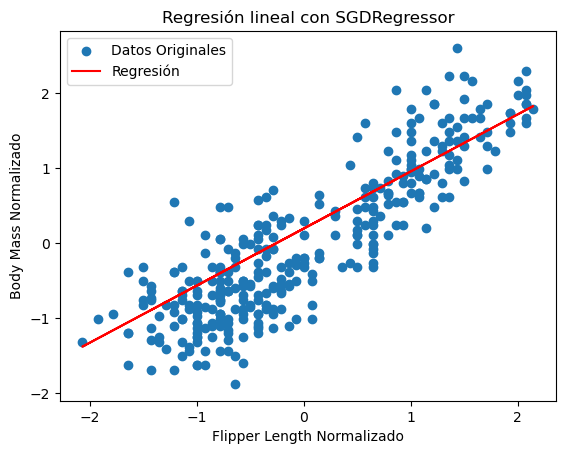

Predicción de Body mass para un flipper_lenght de 210 [4759.38881854]


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Librerias para el descenso de gradiente
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler

# Cargadmos nuestro dataset

penguins_df = sns.load_dataset('penguins').dropna()
print(penguins_df)

# Definimos variable dependiente e independiente (x e y)
X = penguins_df[['flipper_length_mm']].values
y = penguins_df['body_mass_g'].values

print(X,y)

# Realizamos la normalización de los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

y_scaled = (y - np.mean(y)) / np.std(y) # normalización manual
y_scaled

#Definir el modelo de descenso del gradiente
model = SGDRegressor(max_iter=1000,learning_rate='optimal',eta0=0.01)
model.fit(X_scaled,y_scaled)
y_pred = model.predict(X_scaled)
y_pred

#Graficamos los resultados
plt.scatter(X_scaled,y_scaled,label='Datos Originales')
plt.plot(X_scaled,y_pred,color='red',label='Regresión')
plt.xlabel("Flipper Length Normalizado")
plt.ylabel("Body Mass Normalizado")
plt.title("Regresión lineal con SGDRegressor")
plt.legend()
plt.show()

#predicción
nuevo_valor = np.array([[210]])
nuevo_valor_scaled = scaler.transform(nuevo_valor)
prediccion_scaled = model.predict(nuevo_valor_scaled)
prediccion_real = prediccion_scaled * np.std(y) + np.mean(y)
print(f'Predicción de Body mass para un flipper_lenght de 210 {prediccion_real}')